# Cleaner CNN Training

This notebook covers:
- 3.1 Imports & load dataset
- 3.2 CNN architecture (4 conv blocks + 2 dense blocks)
- 3.3 DataLoader & train/val split
- 3.4 Training loop
- 3.5 Loss & accuracy curves
- 3.6 Evaluation on test samples
- 3.7 Save model checkpoint

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from routing_env import *

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

gymnasium available
NumPy: 2.2.6
All imports OK
Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)
Using device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
# Load cleaner dataset
with open('data/cleaner_dataset.pkl', 'rb') as f:
    cleaner_data = pickle.load(f)

X = cleaner_data['X']  # (N, 7, 5, 5)
y = cleaner_data['y']  # (N,)

print(f"Cleaner dataset loaded")
print(f"  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"  Classes : {np.unique(y)} (Net 0, Net 1, Net 2)")
print(f"  Label distribution:")
for i in range(NUM_NETS):
    count = int(np.sum(y == i))
    print(f"    Net {i}: {count} ({count/len(y)*100:.1f}%)")

Cleaner dataset loaded
  X shape : (9428, 7, 5, 5)
  y shape : (9428,)
  Classes : [0 1 2] (Net 0, Net 1, Net 2)
  Label distribution:
    Net 0: 3166 (33.6%)
    Net 1: 3102 (32.9%)
    Net 2: 3160 (33.5%)


In [3]:
# Diagnose data quality
ambiguous = 0
for state, label in zip(X, y):
    congestion = state[C_CONGESTION]
    overlap_per_net = []
    for net_idx in range(NUM_NETS):
        path_layer = state[C_PATH_START + net_idx]
        overlap_cells = int(np.sum((path_layer > 0) & (congestion > 1)))
        overlap_per_net.append(overlap_cells)
    max_val = max(overlap_per_net)
    candidates = [i for i, v in enumerate(overlap_per_net) if v == max_val]
    if len(candidates) > 1:
        ambiguous += 1

print(f"Total samples    : {len(y)}")
print(f"Ambiguous labels : {ambiguous} ({ambiguous/len(y)*100:.1f}%)")
print(f"Clear labels     : {len(y)-ambiguous} ({(1-ambiguous/len(y))*100:.1f}%)")

Total samples    : 9428
Ambiguous labels : 8500 (90.2%)
Clear labels     : 928 (9.8%)


In [4]:
# Filter to unambiguous samples only
clear_indices = []
for i, state in enumerate(X):
    congestion = state[C_CONGESTION]
    overlap_per_net = []
    for net_idx in range(NUM_NETS):
        path_layer = state[C_PATH_START + net_idx]
        overlap_cells = int(np.sum((path_layer > 0) & (congestion > 1)))
        overlap_per_net.append(overlap_cells)
    max_val = max(overlap_per_net)
    candidates = [i for i, v in enumerate(overlap_per_net) if v == max_val]
    if len(candidates) == 1:
        clear_indices.append(i)

X = X[clear_indices]
y = y[clear_indices]

print(f"Filtered dataset : {len(y)} unambiguous samples")
print(f"Label distribution:")
for i in range(NUM_NETS):
    count = int(np.sum(y == i))
    print(f"  Net {i}: {count} ({count/len(y)*100:.1f}%)")

Filtered dataset : 928 unambiguous samples
Label distribution:
  Net 0: 303 (32.7%)
  Net 1: 299 (32.2%)
  Net 2: 326 (35.1%)


## 3.2: CNN Architecture

Following Gandhi et al. (2019): 4 convolutional blocks + 2 dense blocks.
Input: `(7, 5, 5)` state tensor → Output: logits over 3 net classes.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CleanerCNN(nn.Module):
    def __init__(self, in_channels=NUM_CHANNELS, num_classes=NUM_NETS):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )

        self._flat_size = 128 * GRID_SIZE * GRID_SIZE

        self.dense_blocks = nn.Sequential(
            nn.Linear(self._flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.dense_blocks(x)
        return x


# Test architecture
model = CleanerCNN().to(device)
dummy = torch.zeros(4, NUM_CHANNELS, GRID_SIZE, GRID_SIZE).to(device)
out = model(dummy)
print(f"CleanerCNN forward pass OK")
print(f"  Input shape  : {dummy.shape}")
print(f"  Output shape : {out.shape}")
print(f"  Parameters   : {sum(p.numel() for p in model.parameters()):,}")

CleanerCNN forward pass OK
  Input shape  : torch.Size([4, 7, 5, 5])
  Output shape : torch.Size([4, 3])
  Parameters   : 1,738,947


## 3.3: Dataset and DataLoader

In [6]:
class CleanerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# 80/10/10 train/val/test split
dataset    = CleanerDataset(X, y)
total      = len(dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset splits:")
print(f"  Train : {len(train_set):,} samples ({len(train_loader)} batches)")
print(f"  Val   : {len(val_set):,} samples ({len(val_loader)} batches)")
print(f"  Test  : {len(test_set):,} samples ({len(test_loader)} batches)")
print(f"  Batch size: {BATCH_SIZE}")

Dataset splits:
  Train : 742 samples (12 batches)
  Val   : 92 samples (2 batches)
  Test  : 94 samples (2 batches)
  Batch size: 64


## 3.4: Training Loop

In [7]:
# Hyperparameters
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
PATIENCE      = 40

# Model, loss, optimizer, scheduler
model     = CleanerCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss  = float('inf')
patience_count = 0
os.makedirs('checkpoints', exist_ok=True)


def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), 'checkpoints/cleaner_best.pt')
        flag = " best"
    else:
        patience_count += 1
        flag = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.4f} {train_acc*100:>9.1f}% "
              f"{val_loss:>10.4f} {val_acc*100:>8.1f}%{flag}")

    # Early stopping
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Starting training for 100 epochs...
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       1.1560      47.2%     1.0720     39.1% best
     5       0.2576      89.1%     0.7805     76.1%
    10       0.1298      94.6%     0.8883     78.3%
    15       0.0529      97.6%     1.0248     76.1%
    20       0.0410      97.6%     1.0860     77.2%
    25       0.0385      97.8%     1.1309     77.2%
    30       0.0307      98.5%     1.1330     78.3%
    35       0.0310      98.8%     1.1544     77.2%
    40       0.0328      98.0%     1.1724     77.2%

Early stopping at epoch 44 (no improvement for 40 epochs)

Training complete. Best val loss: 0.5538


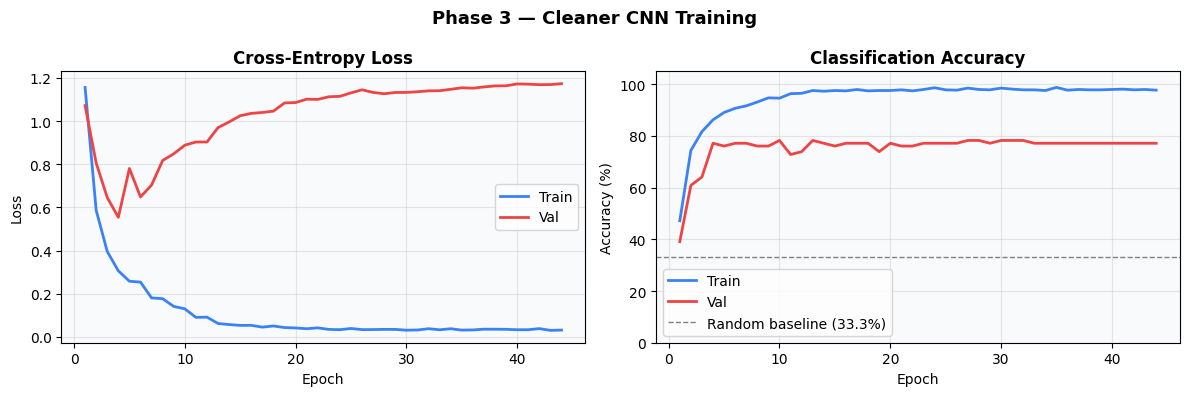

Training curves saved


In [8]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phase 3 — Cleaner CNN Training', fontsize=13, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], color='#3B82F6', linewidth=2, label='Train')
ax.plot(epochs, history['val_loss'],   color='#EF4444', linewidth=2, label='Val')
ax.set_title('Cross-Entropy Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.set_facecolor('#F8FAFC')
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs, [a*100 for a in history['train_acc']], color='#3B82F6', linewidth=2, label='Train')
ax.plot(epochs, [a*100 for a in history['val_acc']],   color='#EF4444', linewidth=2, label='Val')
ax.axhline(y=33.3, color='gray', linestyle='--', linewidth=1, label='Random baseline (33.3%)')
ax.set_title('Classification Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.set_facecolor('#F8FAFC')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Training curves saved')

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load('checkpoints/cleaner_best.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(device))
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

print(f"Test Accuracy: {test_acc*100:.2f}%")
print()

# Per-class accuracy
print("Per-class accuracy:")
for i in range(NUM_NETS):
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).mean()
    print(f"  Net {i}: {acc*100:.1f}%  ({mask.sum()} samples)")

# Confusion matrix
print("\nConfusion matrix (rows=actual, cols=predicted):")
cm = np.zeros((NUM_NETS, NUM_NETS), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm[true][pred] += 1

print(f"  {'':8}", end="")
for i in range(NUM_NETS):
    print(f"  Pred {i}", end="")
print()
for i in range(NUM_NETS):
    print(f"  Act {i}  ", end="")
    for j in range(NUM_NETS):
        print(f"  {cm[i][j]:6d}", end="")
    print()

Test Accuracy: 81.91%

Per-class accuracy:
  Net 0: 78.6%  (28 samples)
  Net 1: 88.0%  (25 samples)
  Net 2: 80.5%  (41 samples)

Confusion matrix (rows=actual, cols=predicted):
            Pred 0  Pred 1  Pred 2
  Act 0        22       1       5
  Act 1         2      22       1
  Act 2         4       4      33


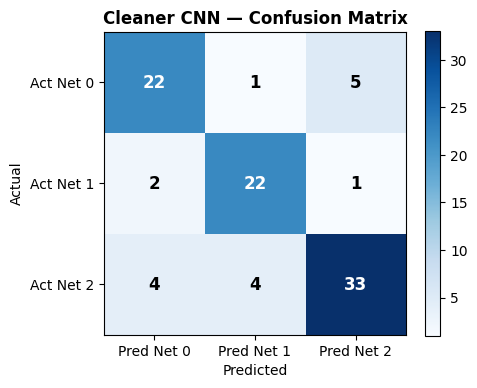

Confusion matrix saved


In [10]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_NETS))
ax.set_yticks(range(NUM_NETS))
ax.set_xticklabels([f'Pred Net {i}' for i in range(NUM_NETS)])
ax.set_yticklabels([f'Act Net {i}'  for i in range(NUM_NETS)])

for i in range(NUM_NETS):
    for j in range(NUM_NETS):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black',
                fontsize=12, fontweight='bold')

ax.set_title('Cleaner CNN — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('phase3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Confusion matrix saved')

In [11]:
# Save full checkpoint with metadata
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_val_loss': best_val_loss,
    'test_acc': test_acc,
    'config': {
        'in_channels':  NUM_CHANNELS,
        'num_classes':  NUM_NETS,
        'grid_size':    GRID_SIZE,
        'num_epochs':   NUM_EPOCHS,
        'lr':           LEARNING_RATE,
        'batch_size':   BATCH_SIZE,
    }
}

torch.save(checkpoint, 'checkpoints/cleaner_final.pt')
print(f"Full checkpoint saved to checkpoints/cleaner_final.pt")

print()
print("  Phase 3 Summary")
print(f"   Architecture   : 4 conv + 2 dense blocks")
print(f"   Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"   Best val loss  : {best_val_loss:.4f}")
print(f"   Test accuracy  : {test_acc*100:.2f}%")
print(f"   Checkpoint     : checkpoints/cleaner_best.pt")
print()
print(" Ready for Phase 4: Router CNN + MCTS")

Full checkpoint saved to checkpoints/cleaner_final.pt

  Phase 3 Summary
   Architecture   : 4 conv + 2 dense blocks
   Parameters     : 1,738,947
   Best val loss  : 0.5538
   Test accuracy  : 81.91%
   Checkpoint     : checkpoints/cleaner_best.pt

 Ready for Phase 4: Router CNN + MCTS
